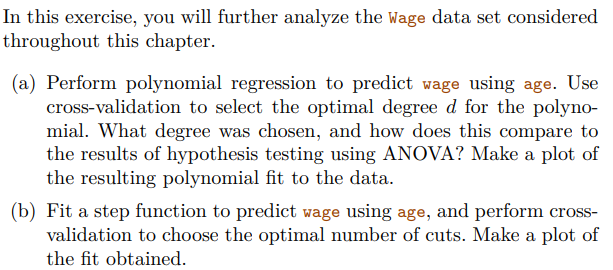

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install ISLP
from ISLP import load_data
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0c9659bf79299f50969c70e49a833ac1e31e3d91807096f84cdce0626f5bf240
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


Best polynomial degree: 8


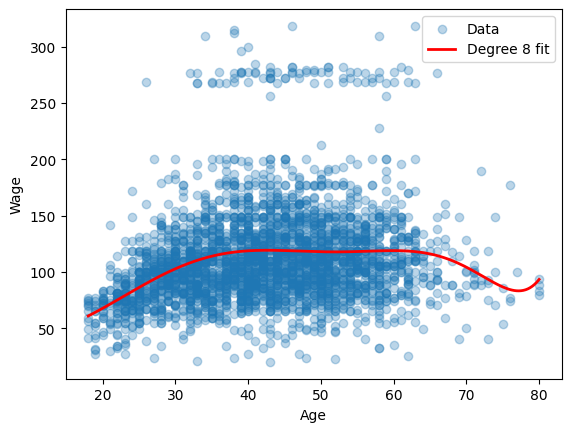

In [4]:
wage = load_data("Wage")
X = wage[['age']]
y = wage['wage']
X = wage[['age']].values
y = wage['wage'].values

degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
cv_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    # 10-fold CV, negative MSE
    scores = cross_val_score(model, X_poly, y, cv=10, scoring='neg_mean_squared_error')
    cv_errors.append(-scores.mean())

best_degree = degrees[np.argmin(cv_errors)]
print("Best polynomial degree:", best_degree)

# Fit best polynomial
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

# Plot
age_grid = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
preds = model.predict(poly.transform(age_grid))

plt.scatter(X, y, alpha=0.3, label="Data")
plt.plot(age_grid, preds, color="red", linewidth=2, label=f"Degree {best_degree} fit")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.legend()
plt.show()

Best number of cuts: 16


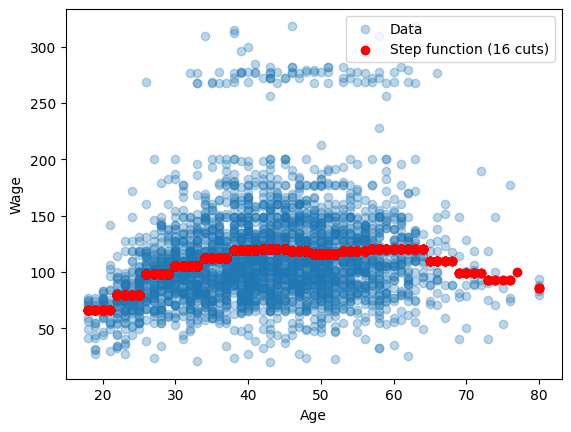

In [5]:
from sklearn.model_selection import KFold

def step_function(X, y, n_bins):
    bins = np.linspace(X.min(), X.max(), n_bins+1)
    X_binned = np.digitize(X, bins)
    # Force all categories to appear
    X_step = pd.get_dummies(X_binned.flatten())
    X_step = X_step.reindex(columns=range(1, n_bins+1), fill_value=0)
    model = LinearRegression().fit(X_step.values, y)
    return model, bins

cuts = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
cv_errors_step = []

for c in cuts:
    kf = KFold(n_splits=10, shuffle=True, random_state=1)
    mse_list = []
    for train_idx, test_idx in kf.split(X):
        model, bins = step_function(X[train_idx], y[train_idx], c)
        # Bin test data
        X_binned_test = np.digitize(X[test_idx], bins)
        X_step_test = pd.get_dummies(X_binned_test.flatten())
        # Reindex to ensure same columns as training
        X_step_test = X_step_test.reindex(columns=range(1, c+1), fill_value=0)
        preds = model.predict(X_step_test.values)
        mse = ((y[test_idx] - preds)**2).mean()
        mse_list.append(mse)
    cv_errors_step.append(np.mean(mse_list))

best_cuts = cuts[np.argmin(cv_errors_step)]
print("Best number of cuts:", best_cuts)

# Fit final step function
model, bins = step_function(X, y, best_cuts)
X_binned = np.digitize(X, bins)
X_step = pd.get_dummies(X_binned.flatten()).reindex(columns=range(1, best_cuts+1), fill_value=0).values
preds = model.predict(X_step)

plt.scatter(X, y, alpha=0.3, label="Data")
plt.scatter(X, preds, color="red", label=f"Step function ({best_cuts} cuts)")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.legend()
plt.show()